## Встроенная функция filter()

Часто требуется отобрать из последовательности элементы, удовлетворяющие определённому условию. Например, из списка пользовательских оценок видеоигры необходимо выделить только те, что выше 70 баллов. Такая операция называется фильтрацией — мы отсекаем данные, которые не проходят фильтр.

Мы уже решали подобные задачи с помощью цикла и условного оператора, но теперь мы расширим наши возможности с помощью специальных функций.

Посмотрим, как можно производить фильтрацию в итерируемых объектах с помощью встроенной функции filter(). Начнём с простого примера

** Пример №1

Условие задачи

Пусть у нас задан список слов words_list:

In [2]:
words_list = ["We're", 'in', 'a', 'small', 'village', 'near', 'Chicago', 'My', "cousin's", 'getting', 'married.']

Необходимо создать новый список even_list, содержащий только те слова из списка words_list, длина которых чётная. Например, если программа будет выполняться для списка, представленного выше, мы должны получить новый список следующего содержания:

['in', 'near', 'My', "cousin's", 'married.']

задачу можно решить с помощью специальной, встроенной в Python функции filter(). Она позволяет отфильтровать переданный в неё итерируемый объект и оставить в нём только те элементы, которые удовлетворяют условию.

Её использование аналогично применению функции map(). Аргументы функции filter() следующие:

первый — функция, которая должна возвращать True, если условие выполнено, иначе возвращается False;

второй — итерируемый объект, с которым производится действие.

In [3]:
# Объявляем функцию для проверки чётности длины строки
def is_even(x):
    return len(x) % 2 == 0

In [4]:
# Применяем функцию is_even() к каждому элементу списка
# Для этого передаём функцию is_even() и список words_list в функцию filter
even = filter(is_even, words_list)
# Смотрим, что получилось 
print(even)

Примечание. Функция filter() возвращает объект типа filter, который, как и объект map(), является итератором. Поэтому результат работы функции filter() стоит обернуть в список с помощью функции list().

In [5]:
# Применяем функцию is_even() к каждому элементу списка
# Для этого передаём функцию is_even() и список words_list в функцию filter
# Результат оборачиваем в список
even_list = list(filter(is_even, words_list))
# Смотрим, что получилось 
print(even_list)

['in', 'near', 'My', "cousin's", 'married.']


## FILTER + LAMBDA

In [6]:
words_list = ["We're", 'in', 'a', 'small', 'village', 'near', 'Chicago', 'My', "cousin's", 'getting', 'married.']

# Применяем lambda-функцию к каждому элементу списка
even_list = filter(lambda x: len(x) % 2 == 0, words_list)
# Смотрим, что получилось
print(list(even_list))

['in', 'near', 'My', "cousin's", 'married.']


** Пример №2

Условие задачи

Пусть у нас есть кортеж из строк. Пример такого кортежа:

In [7]:
str_tuple = ("Москва", "15.1 см", "зацвело", "было пол 5 утра", "рассвет")

Необходимо составить новый кортеж, в котором будут только строки, состоящие только из букв. То есть для примера выше в результирующем кортеже должны быть строки "Москва", "зацвело" и "рассвет".

Решение

Напомним: чтобы проверить, что строка состоит только из букв, используется метод isalpha(). Он возвращает True, если в строке не содержится символов, помимо букв, и False — в противном случае. Примеры:

In [8]:
print("Москва".isalpha())


print("было пол 5 утра".isalpha())

True
False


Тогда напишем lambda-функцию, которая будет применять метод isalpha() к строке, которая передаётся ей в аргументы. Затем отправим эту lambda-функцию в функцию filter() вместе с исходным кортежем, а результат преобразуем в кортеж с помощью функции tuple():

In [9]:
# Применяем lambda-функцию к каждому элементу кортежа
# Результат оборачиваем в кортеж
filtered_tuple = tuple(filter(lambda x: x.isalpha(), str_tuple))
# Смотрим, что получилось
print(filtered_tuple)

('Москва', 'зацвело', 'рассвет')


** Пример №3

Условие задачи

Школа онлайн-образования разрабатывает курс «Fullstack-разработчик» и собирает данные по каждому модулю курса.

В списке кортежей data представлена выгрузка данных из базы данных об оценках бонусных (дополнительных) модулей курса:

In [10]:
data = [
    ("FPW-2.0_D", "Бонус: Тренажер по HTML", 10, 100, 10),
    ("FPW-2.0", "Бонус: Тренажер по JavaScript", 9.2, 70, 180),
    ("FPW-2.0_D", "Бонус: Тренажер по React", 8.5, 66.67, 68),
    ("FPW-2.0", "Бонусный: IT в современном мире", 8.64, 83.74, 856),
    ("FPW-2.0", "Бонусный: Введение", 8.73, 56.24, 745),
    ("FPW-2.0", "Бонус: D1. Знакомство с Django (NEW)", 9.76, 95.24, 21),
    ("FPW-2.0_D", "Бонус: D2. Модели (NEW)", 9.44, 77.78, 18)
]

Данные по каждому модулю представлены в виде кортежей, состоящих из пяти элементов:

Кодовое название курса.
Название курса.
Средняя оценка модуля.
NESSA — это внутренняя метрика компании, показывающая качество модуля (измеряется от 0 до 100).
Количество оценок.
Необходимо выбрать из представленных данных только те модули, которые относятся к курсу FPW-2.0, их NESSA > 70 и количество оценок > 50.

Решение

Как всегда, для решения задачи нам необходимо выделить в отдельную функцию действия, которые мы должны произвести с одним элементом итерируемого объекта (у нас это список). Элементами списка в нашем случае являются кортежи.

Поэтому для начала создадим функцию, которая будет принимать один кортеж с данными о модуле. Внутри себя функция будет распаковывать этот кортеж на пять переменных: code, name, avg_votes, nessa и count.

По условию задачи, нам нужны модули, для которых выполняются одновременно три условия:

Кодовое название курса (code) == "FPW-2.0".

NESSA (nessa) >= 70.

Количество оценок (count) > 50.

Итоговый код функции будет иметь следующий вид:

In [11]:
def filter_module(module):
    # Распаковываем кортеж на пять переменных
    code, name, avg_votes, nessa, count = module
    # Создаём условия 
    cond_1 = code == "FPW-2.0"
    cond_2 = nessa >= 70
    cond_3 = count > 50
    # Условия должны выполняться одновременно
    return cond_1 and cond_2 and cond_3

In [12]:
print(filter_module(module=("FPW-2.0_D", "Бонус: Тренажер по HTML", 10, 100, 10)))

False


In [13]:
print(filter_module(module=("FPW-2.0", "Бонус: Тренажер по JavaScript", 9.2, 70, 180)))

True


In [14]:
# Применяем функцию filter_module() для фильтрации списка кортежей
filtered_data = list(filter(filter_module, data))
print(filtered_data)

[('FPW-2.0', 'Бонус: Тренажер по JavaScript', 9.2, 70, 180), ('FPW-2.0', 'Бонусный: IT в современном мире', 8.64, 83.74, 856)]


Заметим, что при желании функцию filter_module() можно переписать в виде однострочной lambda-функции:

In [15]:
# Создаём lambda-функцию, которая возвращает True, если модуль удовлетворяет условиям
lambda_filter_module = lambda x: (x[0] == "FPW-2.0") and (x[3] >= 70) and (x[4] > 50)
# Применяем эту функцию к каждому элементу списка (к каждому кортежу)
filtered_data = list(filter(lambda_filter_module, data))
# Смотрим, что получилось
print(filtered_data)

[('FPW-2.0', 'Бонус: Тренажер по JavaScript', 9.2, 70, 180), ('FPW-2.0', 'Бонусный: IT в современном мире', 8.64, 83.74, 856)]


** У вас есть список prices стоимости аренды помещения под магазин за месяц. Вам необходимо создать список filtered_prices из стоимости, которая не выше 30000, чтобы уложиться в бюджет. В решении примените filter() и lambda.

In [17]:
prices = [34562, 66572, 25683, 17683, 56389, 28973]
## filtered_prices = [25683, 17683, 28973]
filtered_prices = list(filter((lambda x: x<=30000),prices))
print(filtered_prices)

[25683, 17683, 28973]


------------------------

## КОНВЕЙЕРЫ ИЗ MAP И FILTER

В некоторых случаях необходимо выполнить сразу несколько действий с итерируемыми объектами. Например, вы хотите сначала преобразовать данные об оценках пользователей в видеоигре, переведя оценки в масштаб от 0 до 100, а затем отфильтровать только те оценки, которые выше 70 баллов. Такие преобразования называются конвейерными.

Для построения конвейерных преобразований необязательно каждый раз после применения map() или filter() получать список элементов. Объекты map и filter (на самом деле, как и любые другие итераторы) можно подставлять в эти же функции map() и filter().

** Пример №4

Условие задачи

Вернёмся к нашей задаче из области анализа естественного языка о подсчёте длины слов. Нам дан список слов в предложении words_list:

In [18]:
# Список из слов
words_list = ["We're", 'in', 'a', 'small', 'village', 'near', 'Chicago', 'My', "cousin's", 'getting', 'married.']

Допустим, вначале мы хотим отобрать только те слова, которые состоят из пяти и более букв, а затем посчитать, сколько раз в таких словах встречается буква "a".

Итак, наш алгоритм действий:

Сначала фильтруем список по условию len(x) >= 5 с помощью функции filter(). Для фильтрации воспользуемся lambda-функцией:

In [19]:
lambda x: len(x) >= 5

<function __main__.<lambda>(x)>

Напишем lambda-функцию, которая приводит имя к нижнему регистру с помощью метода строки lower(), а затем методом строки count() вычисляет количество символов "a". Функция должна возвращать кортеж (имя, число букв "a"). Её вид будет следующий:

In [20]:
lambda x: (x, x.lower().count('a'))

<function __main__.<lambda>(x)>

Применим нашу функцию-преобразование к отфильтрованным данным с помощью map().

Конечный результат обернём в список с помощью функции list().

Наш конвейер, состоящий из filter() и map(), будет иметь вид:

In [21]:
# Отбираем слова из пяти и более букв
filtered_words = filter(lambda x: len(x) >= 5, words_list)
# Все отобранные слова переводим в нижний регистр и считаем число букв 'a' в них
# Результат выдаём в виде кортежа (слово, количество букв "a")
count_a = map(lambda x: (x, x.lower().count('a')), filtered_words)
# Переводим объект map в list и печатаем его
print(list(count_a))

[("We're", 0), ('small', 1), ('village', 1), ('Chicago', 1), ("cousin's", 0), ('getting', 0), ('married.', 1)]


Небольшое замечание.

Выгода использования конвейеров без создания списков заключается в повышении быстродействия скрипта.

Когда мы будем более детально изучать итераторы, мы поймём, что при создании итератора на самом деле не происходит самих вычислений. Вычисления происходят только на этапе распаковки итератора в список с помощью функции list().

Это значит, что вы не тратите время на промежуточную распаковку содержимого итератора (объекта map или filter) в список. Распаковка осуществляется только один раз — в момент вызова строки list(count_a). Таким образом немного повышается производительность кода, что может дать существенный бонус при работе с огромными массивами данных, состоящими из миллионов записей.

** Пример №5

Условие задачи

Вернёмся к примеру о генерации признаков (Feature Engineering).

Перед нами снова выгрузка данных о параметрах человеческого тела (только теперь она немного больше), представленная в виде списка кортежей. Один кортеж состоит из трёх элементов (признаков):

имени человека;
его роста (в метрах);

In [22]:
# Выгрузка данных о параметрах человеческого тела
data = [
    ('Amanda', 1.61, 51),
    ('Patricia', 1.65, 61), 
    ('Marcos', 1.91, 101),
    ('Andrey', 1.79, 61),
    ('Nikos', 1.57, 78),
    ('Felicia', 1.63, 56),
    ('Lubov', 1.53, 34)
]

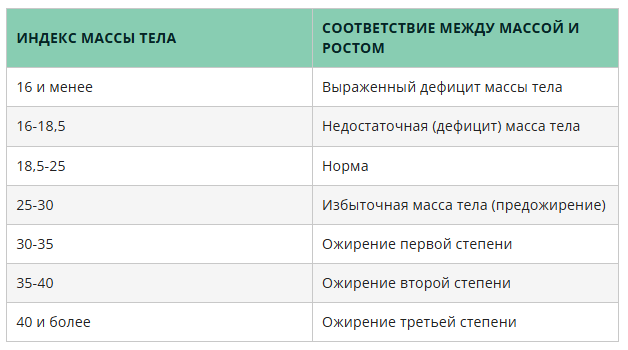

Нам необходимо выбрать из данных только тех пациентов, у кого соотношение массы и роста находится в пределах нормы.

Результатом работы нашей программы должен стать список кортежей, удовлетворяющих условию.

Решение

Вычислять индекс массы тела мы уже умеем (вспомните задачу 5 из предыдущего юнита):

In [23]:
# Создаём lambda-функцию, которая считает BMI, и применяем её к каждому элементу списка
map_func = lambda x: (*x, x[2]/(x[1]**2))
updated_data = map(map_func, data)

Мы получили объект map и записали его в переменную updated_data. Давайте теперь напишем функцию для фильтрации.

Как мы уже обсуждали, выходом map() является кортеж из четырёх элементов (индексы идут от 0 до 3), где элемент под индексом 3 — это интересующий нас BMI.

По условию задачи, мы должны отобрать только тех, у кого BMI находится в пределах нормы (от 18.5 до 25 включительно). Давайте создадим lambda-функцию, которая будет принимать на вход кортеж и возвращать True, если элемент под индексом 3 (BMI) будет находиться в заданных пределах. Применим эту функцию к результату работы map() с помощью функции filter() и обернём результат в список.

Итоговый код будет выглядеть следующим образом:

In [24]:
# Создаём lambda-функцию, которая считает BMI, и применяем её к каждому элементу списка
map_func = lambda x: (*x, x[2]/(x[1]**2))
updated_data = map(map_func, data)
# Создаём lambda-функцию, которая возвращает True, если 18.5 <= BMI <= 25
filter_func = lambda x: 18.5 <= x[3] <= 25
# Применяем эту функцию к результату работы map()
filtered_data = filter(filter_func, updated_data)
# Переводим объект filter в list и печатаем его
print(list(filtered_data))

[('Amanda', 1.61, 51, 19.675166853130666), ('Patricia', 1.65, 61, 22.4058769513315), ('Andrey', 1.79, 61, 19.038107424861895), ('Felicia', 1.63, 56, 21.077195227520797)]


** Мы снова занимаемся регистрацией пользователей. В нашем распоряжении есть список кортежей reg. В каждом кортеже хранится информация о зарегистрированном пользователе и его дате рождения в формате: Фамилия, Имя, день, месяц, год:

In [25]:
reg = [('Ivanov', 'Sergej', 24, 9, 1995),
      ('Smith', 'John', 13, 2, 2003),
      ('Petrova', 'Maria', 13, 3, 2003)]


Выберите из списка reg только те записи, в которых год рождения пользователя больше 2000 (2001, 2002 и т. д.). Из оставшихся записей составьте новый список кортежей, в котором фамилия и имя объединены в одну строку по следующему шаблону: Фамилия И.

Обратите внимание на точку после сокращения имени!

In [26]:
filtered_reg = filter((lambda x: (x[4]>2000)),reg)
new_reg = list(map(lambda x: (x[0]+' '+(x[1][0:1]+'.'),x[2],x[3],x[4]),filtered_reg))
print(new_reg)

[('Smith J.', 13, 2, 2003), ('Petrova M.', 13, 3, 2003)]


** Вернёмся к задаче по оценке стоимости недвижимости.

В списке data представлены усреднённые данные по домам в районах Бостона. Каждый вложенный в список кортеж описывает средние данные по одному району (для примера представлены данные о семи участках). В этом кортеже представлены следующие признаки (в порядке следования):

x₁ — уровень преступности на душу населения по городам;
x₂ — среднее количество комнат в доме;
x₃ — доля зданий, построенных до 1940 г. и занимаемых владельцами;
x₄ — полная ставка налога на имущество за каждые 10 000 долларов стоимости;
x₅ — процент населения с низким статусом.

In [27]:
data = [(0.00632, 6.575, 65.2, 296.0, 4.98),
 (0.02731, 6.421, 78.9, 242.0, 9.14),
 (0.02729, 7.185, 61.1, 242.0, 4.03),
 (0.03237, 6.998, 45.8, 222.0, 2.94),
 (0.06905, 7.147, 54.2, 222.0, 5.33),
 (0.02985, 6.43, 58.7, 222.0, 5.21),
 (0.08829, 6.012, 66.6, 311.0, 12.43)]


Добавьте в набор данных новый признак, который будет равен произведению трёх признаков — x₁, x₄ и x₅. А затем выберите из исходного списка только те данные, для которых значение нового признака > 60.

В результате выполнения программы у вас должен получиться список кортежей. Каждый кортеж должен состоять из шести элементов: первые пять — исходные признаки, а шестой элемент — сгенерированный признак, округлённый до двух знаков после запятой. Результирующий список кортежей занесите в переменную filtered_data.

In [29]:
data_map = map((lambda x: (*x,round((x[0]*x[3]*x[4]),2))), data)
#print(list(data_map))
filtered_data = list(filter((lambda x: x[5]>60),data_map))
print(filtered_data)

[(0.02731, 6.421, 78.9, 242.0, 9.14, 60.41), (0.06905, 7.147, 54.2, 222.0, 5.33, 81.7), (0.08829, 6.012, 66.6, 311.0, 12.43, 341.31)]
